In [ ]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path('/content/drive/Shareddrives/KN Solvro/03. Projekty/Wakacyjne Wyzwanie 20256/ML/notebooki/1_Przetwarzanie i wizualizacja danych') # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)

titanic_df = pd.read_csv("titanic.csv", index_col="PassengerId")

print(titanic_df.shape)
titanic_df.head()

(891, 11)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Wstępne przetwarzanie danych**

In [2]:
df = titanic_df.copy()


df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
})
df.loc[~df['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master']), 'Title'] = 'Rare'

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Deck'] = df['Cabin'].str[0].fillna('Unknown')
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked', 'Title', 'Deck'], drop_first=True)
cols_to_drop = ['Name', 'Ticket', 'Cabin']
df = df.drop(columns=cols_to_drop)

y = df['Survived']
X = df.drop(columns=['Survived'])

print("X:", X.shape)
print("Y:", y.shape)
print("\nX Columns:")
print(X.columns.tolist())
X.head()

X: (891, 22)
Y: (891,)

X Columns:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,3,0,22.0,1,0,7.2500,2,0,False,True,...,False,False,False,False,False,False,False,False,False,True
2,1,1,38.0,1,0,71.2833,2,0,False,False,...,True,False,False,True,False,False,False,False,False,False
3,3,1,26.0,0,0,7.9250,1,1,False,True,...,False,False,False,False,False,False,False,False,False,True
4,1,1,35.0,1,0,53.1000,2,0,False,True,...,True,False,False,True,False,False,False,False,False,False
5,3,0,35.0,0,0,8.0500,1,1,False,True,...,False,False,False,False,False,False,False,False,False,True


**Train/Test + Baseline**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Odsetek osób, które przeżyły - train:", round(y_train.mean(), 3))
print("Odsetek osób, które przeżyły - test: ", round(y_test.mean(), 3))

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy_train = dummy.predict(X_train)
y_pred_dummy_test  = dummy.predict(X_test)

print("\n--- Dummy Classifier ---")
print("Accuracy train:", round(accuracy_score(y_train, y_pred_dummy_train), 3))
print("Accuracy test: ", round(accuracy_score(y_test, y_pred_dummy_test), 3))
print("F1 test:       ", round(f1_score(y_test, y_pred_dummy_test), 3))

Train: (712, 22) (712,)
Test:  (179, 22) (179,)
Odsetek osób, które przeżyły - train: 0.383
Odsetek osób, które przeżyły - test:  0.385

--- Dummy Classifier ---
Accuracy train: 0.617
Accuracy test:  0.615
F1 test:        0.0


**Drzewo decyzyjne + badanie hiperparametrów**

--- Drzewo decyzyjne (domyślne) ---
Dokładność (Accuracy) train: 0.983
Dokładność (Accuracy) test:  0.788
F1-score test:               0.721

Top 10 najlepszych kombinacji według F1:
max_depth  min_samples_leaf  accuracy_test  f1_test
        4                 1       0.826816 0.770370
        4                 3       0.826816 0.770370
        3                 3       0.826816 0.766917
        3                 5       0.826816 0.766917
        4                10       0.826816 0.766917
        3                10       0.826816 0.766917
        3                 1       0.826816 0.766917
        4                 5       0.815642 0.759124
        3                20       0.815642 0.755556
       10                20       0.804469 0.744526


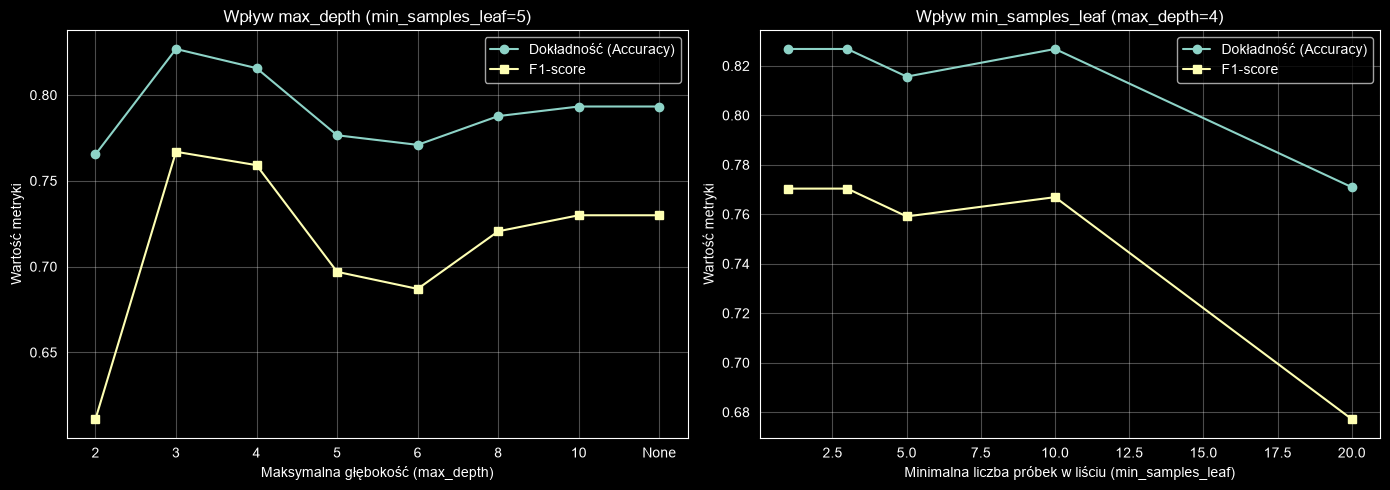

In [4]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree_train = tree.predict(X_train)
y_pred_tree_test  = tree.predict(X_test)

print("--- Drzewo decyzyjne (domyślne) ---")
print("Dokładność (Accuracy) train:", round(accuracy_score(y_train, y_pred_tree_train), 3))
print("Dokładność (Accuracy) test: ", round(accuracy_score(y_test, y_pred_tree_test), 3))
print("F1-score test:              ", round(f1_score(y_test, y_pred_tree_test), 3))

depths = [2, 3, 4, 5, 6, 8, 10, None]
min_leaves = [1, 3, 5, 10, 20]

results = []

for depth in depths:
    for leaf in min_leaves:
        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42
        )
        model.fit(X_train, y_train)

        pred_test = model.predict(X_test)

        results.append({
            'max_depth': depth if depth is not None else 'None',
            'min_samples_leaf': leaf,
            'accuracy_test': accuracy_score(y_test, pred_test),
            'f1_test': f1_score(y_test, pred_test)
        })

results_df = pd.DataFrame(results)
print("\nTop 10 najlepszych kombinacji według F1:")
print(results_df.sort_values('f1_test', ascending=False).head(10).to_string(index=False))

# --- Wizualizacja ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wpływ max_depth (dla stałego min_samples_leaf=5)
subset_depth = results_df[results_df['min_samples_leaf'] == 5]
axes[0].plot(subset_depth['max_depth'].astype(str), subset_depth['accuracy_test'], marker='o', label='Dokładność (Accuracy)')
axes[0].plot(subset_depth['max_depth'].astype(str), subset_depth['f1_test'], marker='s', label='F1-score')
axes[0].set_title('Wpływ max_depth (min_samples_leaf=5)')
axes[0].set_xlabel('Maksymalna głębokość (max_depth)')
axes[0].set_ylabel('Wartość metryki')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Wpływ min_samples_leaf (dla stałego max_depth=4)
subset_leaf = results_df[results_df['max_depth'] == 4]
axes[1].plot(subset_leaf['min_samples_leaf'], subset_leaf['accuracy_test'], marker='o', label='Dokładność (Accuracy)')
axes[1].plot(subset_leaf['min_samples_leaf'], subset_leaf['f1_test'], marker='s', label='F1-score')
axes[1].set_title('Wpływ min_samples_leaf (max_depth=4)')
axes[1].set_xlabel('Minimalna liczba próbek w liściu (min_samples_leaf)')
axes[1].set_ylabel('Wartość metryki')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**SVM + hiperparametry**

--- SVM (domyślny) ---
Dokładność (Accuracy) train: 0.857
Dokładność (Accuracy) test:  0.816
F1-score test:               0.763

Top 8 najlepszych kombinacji według F1:
    C  gamma  accuracy_test  f1_test
 10.0  0.010       0.821229 0.768116
100.0  0.001       0.821229 0.764706
  1.0  0.010       0.810056 0.742424
  1.0  0.100       0.798883 0.739130
  0.1  0.010       0.804469 0.728682
  0.1  0.100       0.748603 0.716981
 10.0  0.001       0.787709 0.707692
 10.0  1.000       0.765363 0.704225


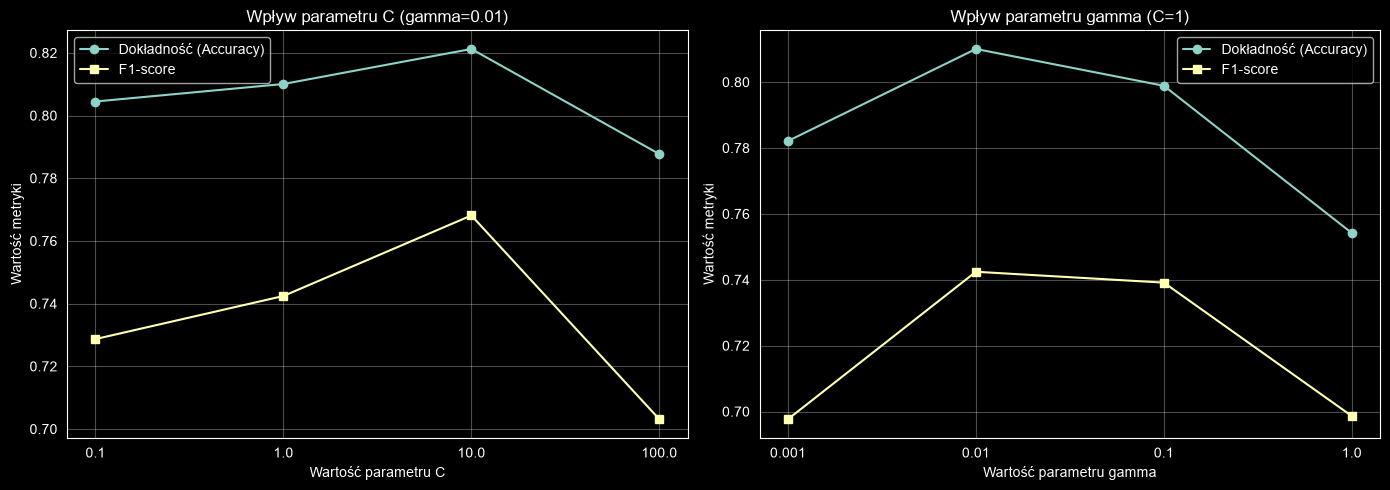

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm_train = svm.predict(X_train_scaled)
y_pred_svm_test  = svm.predict(X_test_scaled)

print("--- SVM (domyślny) ---")
print("Dokładność (Accuracy) train:", round(accuracy_score(y_train, y_pred_svm_train), 3))
print("Dokładność (Accuracy) test: ", round(accuracy_score(y_test, y_pred_svm_test), 3))
print("F1-score test:              ", round(f1_score(y_test, y_pred_svm_test), 3))

C_values = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]

results_svm = []

for C in C_values:
    for gamma in gamma_values:
        model = SVC(C=C, gamma=gamma, random_state=42)
        model.fit(X_train_scaled, y_train)

        pred_test = model.predict(X_test_scaled)

        results_svm.append({
            'C': C,
            'gamma': gamma,
            'accuracy_test': accuracy_score(y_test, pred_test),
            'f1_test': f1_score(y_test, pred_test)
        })

results_svm_df = pd.DataFrame(results_svm)
print("\nTop 8 najlepszych kombinacji według F1:")
print(results_svm_df.sort_values('f1_test', ascending=False).head(8).to_string(index=False))

# --- Wizualizacja ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wpływ parametru C (dla stałego gamma=0.01)
subset_C = results_svm_df[results_svm_df['gamma'] == 0.01]
axes[0].plot(subset_C['C'].astype(str), subset_C['accuracy_test'], marker='o', label='Dokładność (Accuracy)')
axes[0].plot(subset_C['C'].astype(str), subset_C['f1_test'], marker='s', label='F1-score')
axes[0].set_title('Wpływ parametru C (gamma=0.01)')
axes[0].set_xlabel('Wartość parametru C')
axes[0].set_ylabel('Wartość metryki')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Wpływ parametru gamma (dla stałego C=1)
subset_gamma = results_svm_df[results_svm_df['C'] == 1]
axes[1].plot(subset_gamma['gamma'].astype(str), subset_gamma['accuracy_test'], marker='o', label='Dokładność (Accuracy)')
axes[1].plot(subset_gamma['gamma'].astype(str), subset_gamma['f1_test'], marker='s', label='F1-score')
axes[1].set_title('Wpływ parametru gamma (C=1)')
axes[1].set_xlabel('Wartość parametru gamma')
axes[1].set_ylabel('Wartość metryki')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Końcowe porównanie**

In [6]:
best_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=1, random_state=42)
best_tree.fit(X_train, y_train)

best_svm = SVC(C=10, gamma=0.01, random_state=42)
best_svm.fit(X_train_scaled, y_train)

models = {
    'Dummy': (dummy.predict(X_test), dummy.predict(X_train)),
    'Decision Tree (best)': (best_tree.predict(X_test), best_tree.predict(X_train)),
    'SVM (best)': (best_svm.predict(X_test_scaled), best_svm.predict(X_train_scaled))
}

print(f"{'Model':<25} {'Acc train':>10} {'Acc test':>10} {'F1 test':>10}")
print("-" * 55)
for name, (pred_test, pred_train) in models.items():
    acc_tr = accuracy_score(y_train, pred_train)
    acc_te = accuracy_score(y_test, pred_test)
    f1_te  = f1_score(y_test, pred_test)
    print(f"{name:<25} {acc_tr:>10.3f} {acc_te:>10.3f} {f1_te:>10.3f}")

Model                      Acc train   Acc test    F1 test
-------------------------------------------------------
Dummy                          0.617      0.615      0.000
Decision Tree (best)           0.855      0.827      0.770
SVM (best)                     0.857      0.821      0.768


## Obserwacje z EDA, które pomogły

- **Sex** i **Title** – najsilniejsze cechy (kobiety oraz tytuły Mrs/Miss przeżywały wyraźnie częściej).
- **Pclass** – pasażerowie 1. klasy mieli wyższe szanse przeżycia.
- **FamilySize / IsAlone** – osoby samotne i bardzo duże rodziny przeżywały gorzej.
- **Age** – braki uzupełniono medianą (wiek ma znaczenie, szczególnie u dzieci).
- **Cabin → Deck** – słaby, ale użyteczny sygnał.
- Kolumny **Ticket** i **Name** w surowej postaci prawie nic nie wnosiły – usunięto je lub wyciągnięto z nich Title.

## Wybrane metryki

Użyto **Accuracy** i **F1-score**:
- Accuracy – prosta i czytelna miara.
- F1 – ważna przy niezrównoważonych klasach (~38% ocalałych). Dummy osiąga F1 = 0 przy Accuracy ≈ 0,62.

## Wyniki

| Model                 | Acc train | Acc test | F1 test |
|-----------------------|-----------|----------|---------|
| Dummy                 | 0,617     | 0,615    | 0,000   |
| Decision Tree (best)  | ~0,85     | **0,827**| **0,770**|
| SVM (best)            | ~0,85     | **0,821**| **0,768**|

Obie modele są wyraźnie lepsze od Dummy.

## Wnioski dotyczące hiperparametrów

**Decision Tree:**
- Bez ograniczeń mocno się przeucza (0,98 na train vs 0,79 na test).
- Optymalne wartości: `max_depth=3–4`, `min_samples_leaf=1–10`.

**SVM:**
- Wymaga standaryzacji cech.
- Optymalne wartości: `C=10`, `gamma=0.01`.
- Mniej podatny na silne przeuczenie niż głębokie drzewo.

## Podsumowanie

1. Przetwarzanie danych oparte na wnioskach z EDA poprawiło jakość modeli.
2. Poprawny podział train/test oraz baseline (Dummy) są konieczne.
3. Oba modele osiągnęły Accuracy ok. 82–83% i F1 ok. 0,77.
4. Decision Tree wypadł nieznacznie lepiej pod względem F1 i jest łatwiejszy w interpretacji.
5. SVM jest stabilniejszy pod względem różnicy wyników train/test.